In [1]:
list.of.packages <- c("tidyverse","ggfixest","stargazer","data.table","ggpubr","patchwork")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : fixest


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter,

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

WB_bins_labels <- c("<=14°C","14,16]","16,18]","18,20]","20,22]","22,24]","24,26]","26,28]",">28°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

bin_ref_T <-"17,21]"
bin_ref_WB <-"16,18]"

In [3]:
varT <- "T_i30_bin"
varWB <- "WB_i130_bin"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_WB <- setNames(paste0("WBGT: ",WB_bins_labels_pretty), paste0(varWB, "::", WB_bins_labels))

dict <- c(dict_levels_T, dict_levels_WB)

## Mean temperature over days -31 -60 preceding measurement

In [4]:
df_T_31_60 <- read_csv("./4_expo_days_31_60/1_Grid_cell_date_data/output/df_T_cells_CDC_31_60.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_T_31_60), ncol(df_T_31_60))
head(df_T_31_60,2)

[1] "173657 x 5 dataframe"

Measured_date_CDC,cell_x,cell_y,T_i31_60,T_i31_60_bin
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
42474,91.9,27.6,0.8430556,<=17°C
42473,91.9,27.6,0.7833333,<=17°C


In [5]:
df_WB_31_60 <- read_csv("./4_expo_days_31_60/1_Grid_cell_date_data/output/df_WB_cells_CDC_31_60.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_WB_31_60), ncol(df_WB_31_60))
head(df_WB_31_60,2)

[1] "126725 x 5 dataframe"

Measured_date_CDC,cell_x,cell_y,WB_i31_60,WB_i31_60_bin
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
42489,92.5,27.5,4.406944,<=14°C
42490,92.5,27.5,4.523611,<=14°C


In [6]:
df_P_31_60 <- read_csv("./4_expo_days_31_60/1_Grid_cell_date_data/output/df_precip_cells_CDC_31_60.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_P_31_60), ncol(df_P_31_60))
head(df_P_31_60,2)

[1] "126725 x 4 dataframe"

Measured_date_CDC,cell_x,cell_y,P_tot_31_60
<dbl>,<dbl>,<dbl>,<dbl>
42203,92.75,11.75,0.3774295
42205,92.75,9.25,0.2875228


## Mean temperature over days -31 -60 preceding measurement

In [7]:
df_T_61_90 <- read_csv("./5_expo_days_61_90/1_Grid_cell_date_data/output/df_T_cells_CDC_61_90.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_T_61_90), ncol(df_T_61_90))
head(df_T_61_90,2)

[1] "173657 x 5 dataframe"

Measured_date_CDC,cell_x,cell_y,T_i61_90,T_i61_90_bin
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
42474,91.9,27.6,-3.343056,<=17°C
42473,91.9,27.6,-3.468056,<=17°C


In [8]:
df_WB_61_90 <- read_csv("./5_expo_days_61_90/1_Grid_cell_date_data/output/df_WB_cells_CDC_61_90.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_WB_61_90), ncol(df_WB_61_90))
head(df_WB_61_90,2)

[1] "126725 x 5 dataframe"

Measured_date_CDC,cell_x,cell_y,WB_i61_90,WB_i61_90_bin
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
42489,92.50,27.5,1.719444,<=14°C
42474,91.75,27.5,-1.438889,<=14°C


In [9]:
df_P_61_90 <- read_csv("./5_expo_days_61_90/1_Grid_cell_date_data/output/df_precip_cells_CDC_61_90.csv",show_col_types = FALSE)
sprintf("%i x %i dataframe", nrow(df_P_61_90), ncol(df_P_61_90))
head(df_P_61_90,2)

[1] "126725 x 4 dataframe"

Measured_date_CDC,cell_x,cell_y,P_tot_61_90
<dbl>,<dbl>,<dbl>,<dbl>
42203,92.75,11.75,0.1551723
42205,92.75,9.25,0.2097855


# Children

In [10]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [11]:
df_reg_children <- df_children %>%
                        left_join(df_T_31_60,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                        left_join(df_WB_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_P_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_T_61_90,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                        left_join(df_WB_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_P_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                               WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                               T_i31_60_bin=factor(gsub("\\(","",T_i31_60_bin),levels=T_bins_labels),
                               WB_i31_60_bin=factor(gsub("\\(","",WB_i31_60_bin),levels=WB_bins_labels),
                               T_i61_90_bin=factor(gsub("\\(","",T_i61_90_bin),levels=T_bins_labels),
                               WB_i61_90_bin=factor(gsub("\\(","",WB_i61_90_bin),levels=WB_bins_labels)
        )

# Women

In [12]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [13]:
df_reg_women <- df_women %>%
                        left_join(df_T_31_60,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                        left_join(df_WB_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_P_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_T_61_90,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                        left_join(df_WB_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        left_join(df_P_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                        mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                               WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                               T_i31_60_bin=factor(gsub("\\(","",T_i31_60_bin),levels=T_bins_labels),
                               WB_i31_60_bin=factor(gsub("\\(","",WB_i31_60_bin),levels=WB_bins_labels),
                               T_i61_90_bin=factor(gsub("\\(","",T_i61_90_bin),levels=T_bins_labels),
                               WB_i61_90_bin=factor(gsub("\\(","",WB_i61_90_bin),levels=WB_bins_labels)
        )

# Men

In [14]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [15]:
df_reg_men <- df_men %>%
                left_join(df_T_31_60,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                left_join(df_WB_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                left_join(df_P_31_60,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                left_join(df_T_61_90,by=c("Measured_date_CDC","cell_x_01"="cell_x","cell_y_01"="cell_y"))%>%
                left_join(df_WB_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                left_join(df_P_61_90,by=c("Measured_date_CDC","cell_x_025"="cell_x","cell_y_025"="cell_y"))%>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels),
                       T_i31_60_bin=factor(gsub("\\(","",T_i31_60_bin),levels=T_bins_labels),
                       WB_i31_60_bin=factor(gsub("\\(","",WB_i31_60_bin),levels=WB_bins_labels),
                       T_i61_90_bin=factor(gsub("\\(","",T_i61_90_bin),levels=T_bins_labels),
                       WB_i61_90_bin=factor(gsub("\\(","",WB_i61_90_bin),levels=WB_bins_labels)
)

# Hemoglobin level

In [16]:
fe_reg <- function(df,Y_var,T_var,N_days,controls, FE){
    if (T_var == "T"){
        T_bin <- paste0("T_i",N_days,"_bin")
        T_ref <- bin_ref_T
    }
    else{T_bin <- paste0("WB_i",N_days,"_bin")
         T_ref <- bin_ref_WB}
    P_var <- paste0("P_tot_",N_days)
    form <- paste0(Y_var," ~ i(",T_bin,",ref='",T_ref,"') + ", P_var, controls, FE)
    #print(form)
    feols(formula(form),
          vcov = ~District_ID,                    
          df)
}

In [17]:
child_controls <-"+ Child_female + Child_birth_order + Child_alive_age_month + 
                    Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                    Mother_muslim + Mother_not_hindu_nor_muslim  + 
                    Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                    Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                    Urban "

In [18]:
adults_controls <- "+ Current_age + N_year_educ + Smoker + Health_insurance + 
                      Religion_muslim + Religion_not_hindu_nor_muslim + 
                      Ethni_SC + Ethni_ST + Ethni_OBC +
                      Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                      Urban "

In [19]:
FE <- "|District_ID^Measured_month + District_ID^Measured_year"

In [20]:
reg_children_T_61_90 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T","61_90",child_controls,FE)
reg_women_T_61_90 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T","61_90",adults_controls,FE)
reg_men_T_61_90 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T","61_90",adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [21]:
reg_children_WB_61_90 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB","61_90",child_controls,FE)
reg_women_WB_61_90 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB","61_90",adults_controls,FE)
reg_men_WB_61_90 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB","61_90",adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [22]:
reg_children_T_31_60 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T","31_60",child_controls,FE)
reg_women_T_31_60 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T","31_60",adults_controls,FE)
reg_men_T_31_60 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T","31_60",adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [23]:
reg_children_WB_31_60 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB","31_60",child_controls,FE)
reg_women_WB_31_60 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB","31_60",adults_controls,FE)
reg_men_WB_31_60 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB","31_60",adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [24]:
reg_children_T_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","T",30,child_controls,FE)
reg_women_T_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","T",30,adults_controls,FE)
reg_men_T_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","T",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [25]:
reg_children_WB_30 <- fe_reg(df_reg_children,"Child_hemo_level_alti","WB",30,child_controls,FE)
reg_women_WB_30 <- fe_reg(df_reg_women,"Blood_hemo_level_alti","WB",30,adults_controls,FE)
reg_men_WB_30 <- fe_reg(df_reg_men,"Blood_hemo_level_alti","WB",30,adults_controls,FE)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



# Plot

In [26]:
theme_perso <- function(...) {
                  theme(legend.position="bottom",
                        legend.text = element_text(size = 20),
                        plot.title = element_text(size=25),
                        axis.title.x = element_text(size = 20, face = "bold"),
                        axis.text.x =  element_text(size = 20, angle=40, hjust=1),
                        axis.title.y = element_text(size = 20),
                        axis.text.y =  element_text(size = 20))
                }

In [27]:
plot_children_T <- ggiplot(list('-61 -90 days' = reg_children_T_61_90,
                                '-31 -60 days' = reg_children_T_31_60,
                                '-1  -30 days' = reg_children_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_children_WB <- ggiplot(list('-61 -90 days' = reg_children_WB_61_90,
                                 '-31 -60 days' = reg_children_WB_31_60,
                                 '-1  -30 days' = reg_children_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_children <- annotate_figure(ggarrange(plot_children_T,plot_children_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Children", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [28]:
plot_women_T <- ggiplot(list('-61 -90 days' = reg_women_T_61_90,
                             '-31 -60 days' = reg_women_T_31_60,
                             '-1  -30 days' = reg_women_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_women_WB <- ggiplot(list('-61 -90 days' = reg_women_WB_61_90,
                              '-31 -60 days' = reg_women_WB_31_60,
                              '-1  -30 days' = reg_women_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_women <- annotate_figure(ggarrange(plot_women_T,plot_women_WB,
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Women", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [29]:
plot_men_T <- ggiplot(list('-61 -90 days' = reg_men_T_61_90,
                           '-31 -60 days' = reg_men_T_31_60,
                           '-1  -30 days' = reg_men_T_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean Air temp. (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = T_bins_labels,
                                   labels = T_bins_labels_pretty)

plot_men_WB <- ggiplot(list('-61 -90 days' = reg_men_WB_61_90,
                            '-31 -60 days' = reg_men_WB_31_60,
                            '-1  -30 days' = reg_men_WB_30),
                        col = c("firebrick", "steelblue", "forestgreen")
                       ) +
                  labs(title = "\n Effect on hemoglobin level (g/L)",
                       x = "\n Mean WBGT (°C)",
                       y = "Estimate and 95% Conf.Int.") +
                  theme_perso()+
                  scale_x_discrete(limits = WB_bins_labels,
                                   labels = WB_bins_labels_pretty)

options(repr.plot.width=7, repr.plot.height=15, scipen=9999)
plot_men <- annotate_figure(ggarrange(plot_men_T, plot_men_WB, 
                                        nrow = 2, ncol = 1,
                                        common.legend = TRUE, legend = "bottom"),
                              top = text_grob("Men", face="bold", size=30)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


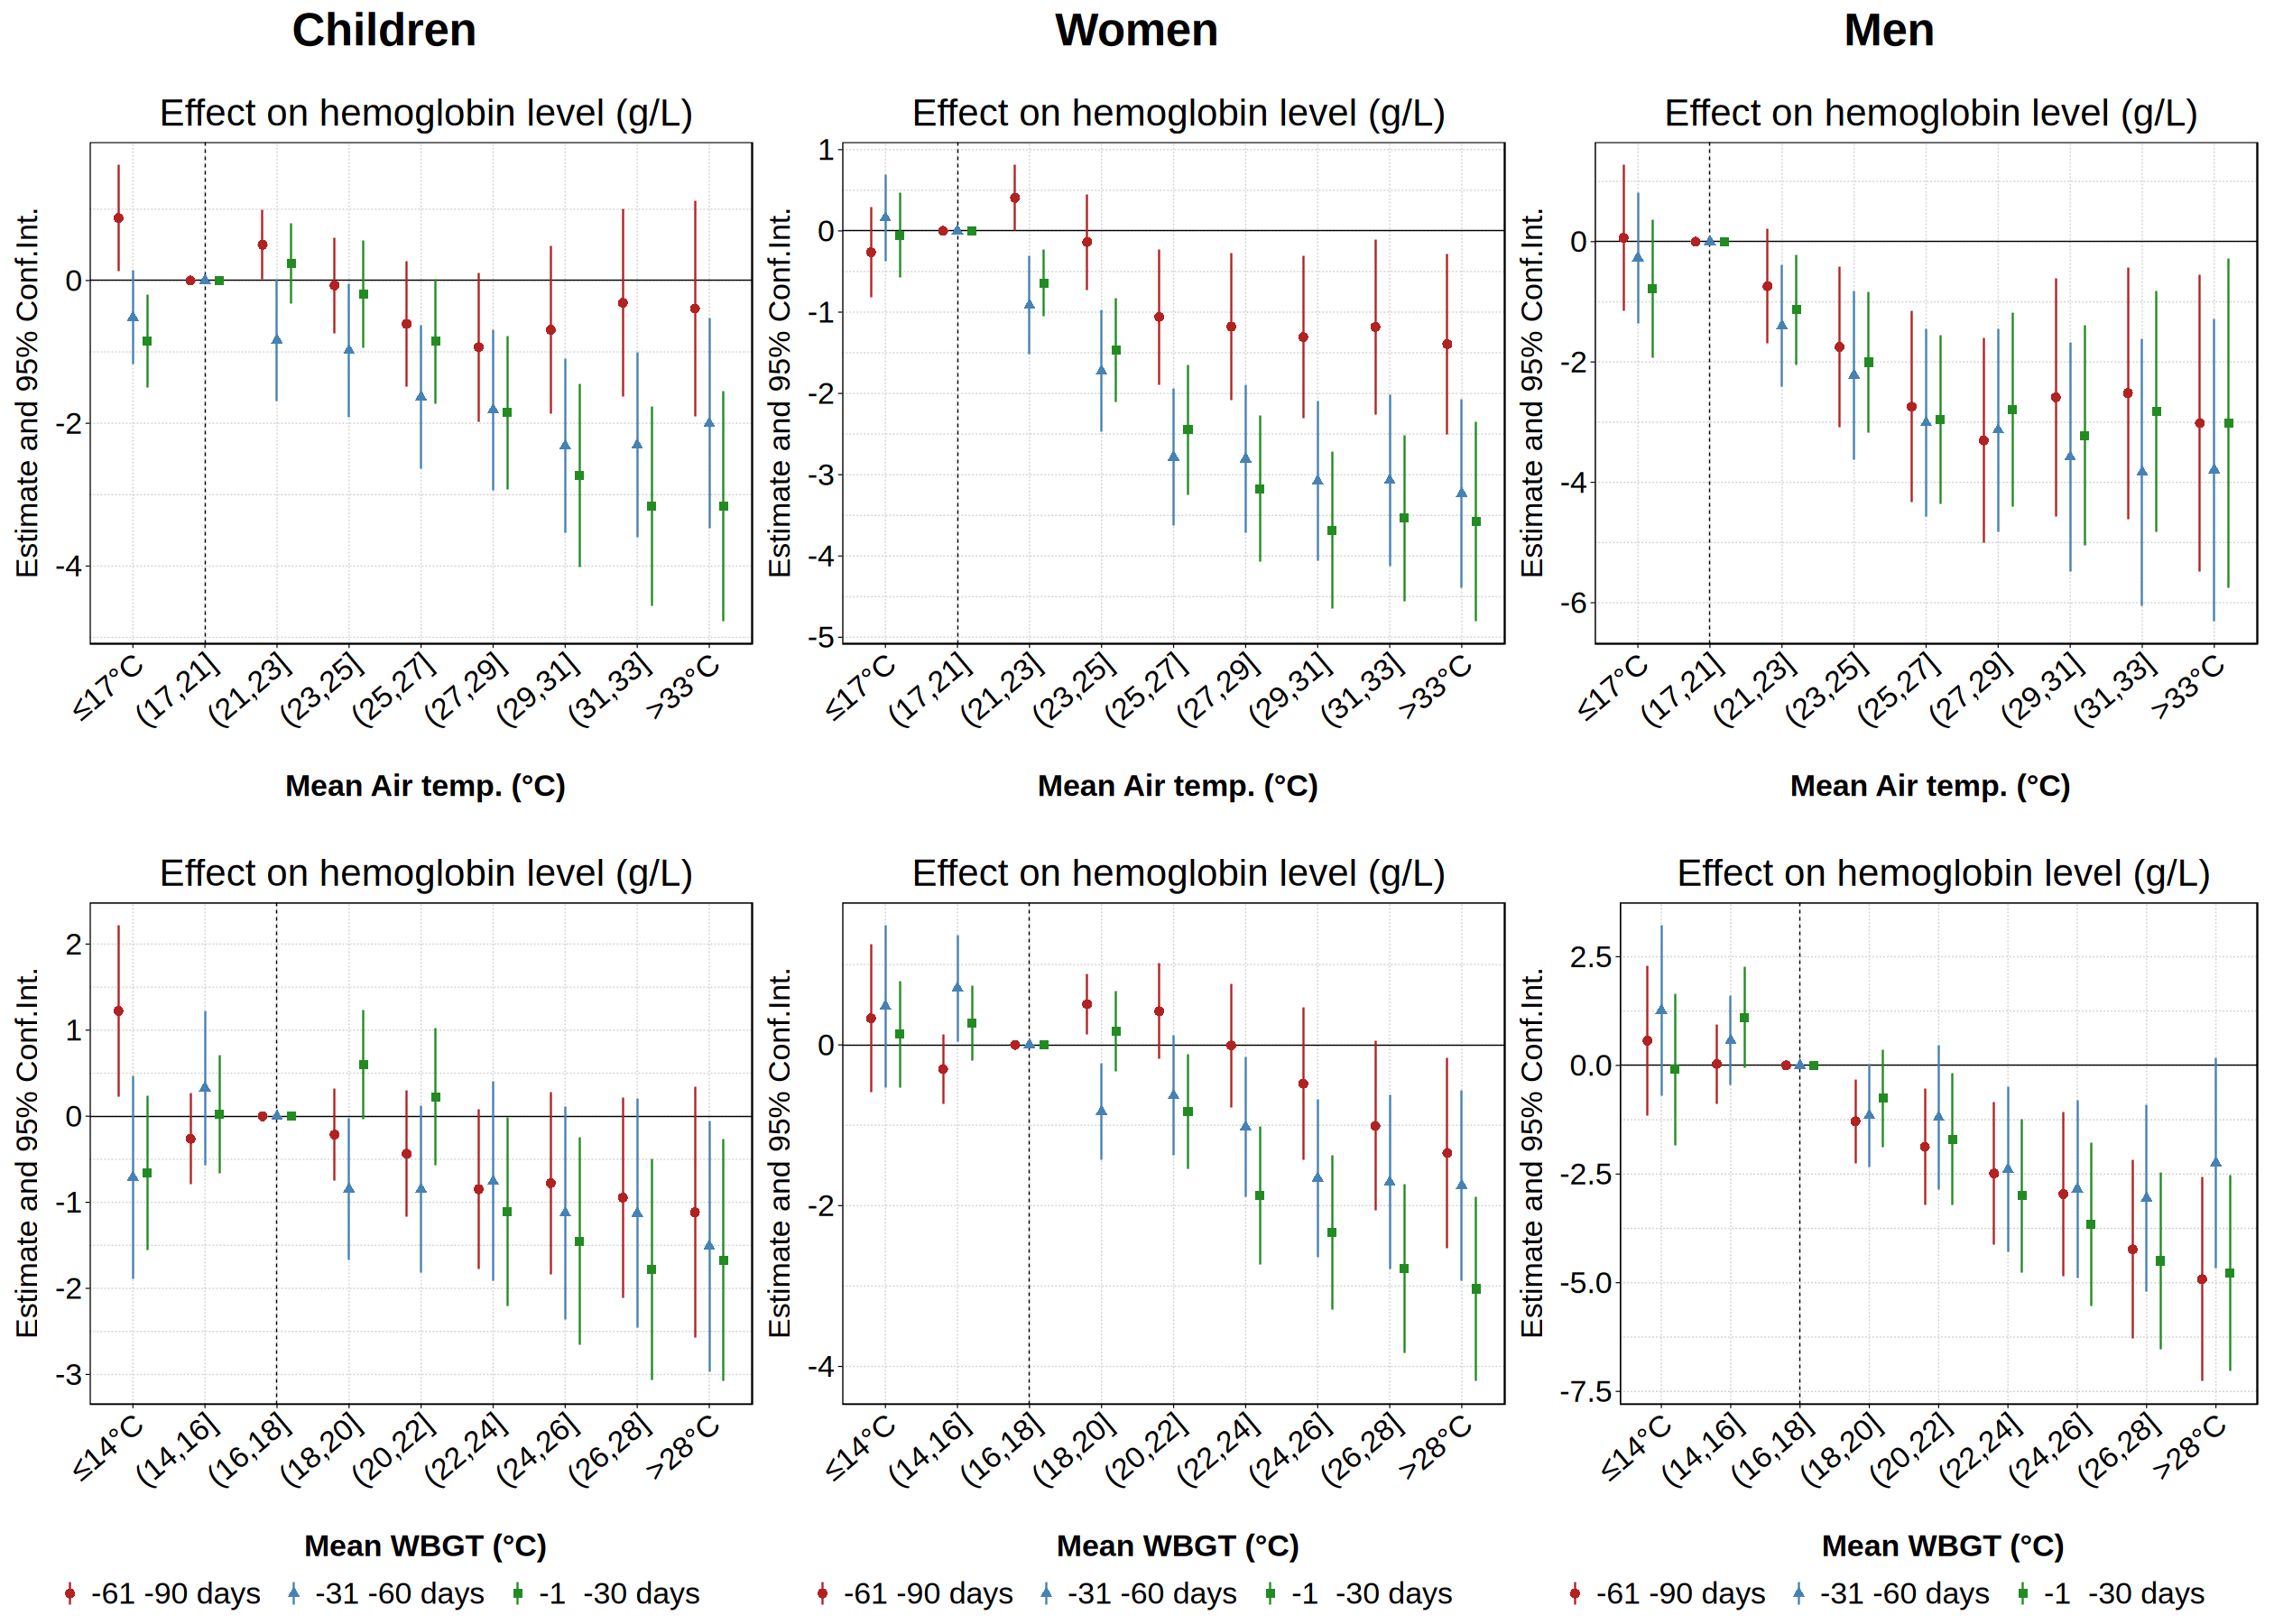

In [30]:
options(repr.plot.width=21, repr.plot.height=15, scipen=9999)

plot_all <- plot_children + plot_women + plot_men +  plot_layout(ncol=3)
plot_all

In [31]:
ggsave("./3_output/img/comp_estimates_30_60_90.png", width=24, height=15, plot_all, device="png")